                               Recommendation System



Objective:

The objective of this assignment is to implement a recommendation system using cosine similarity on an anime dataset.  

Dataset:

Use the Anime Dataset which contains information about various anime, including their titles, genres,No.of episodes and user ratings etc.

Tasks:

Data Preprocessing:

Load the dataset into a suitable data structure (e.g., pandas DataFrame).

Handle missing values, if any.

Explore the dataset to understand its structure and attributes.


In [1]:
import pandas as pd  # Import pandas library for data manipulation
import numpy as np  # Import numpy for numerical operations
import matplotlib.pyplot as plt  # Import matplotlib for data visualization 

In [2]:
dataframe = pd.read_csv('anime.csv')  # Load data from a CSV file into a DataFrame
dataframe

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266
...,...,...,...,...,...,...,...
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,1,4.15,211
12290,5543,Under World,Hentai,OVA,1,4.28,183
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4,4.88,219
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,1,4.98,175


In [3]:
dataframe.head(5)

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [4]:
dataframe.shape

(12294, 7)

In [5]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [6]:
dataframe.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [7]:
dataframe["anime_id"]

0        32281
1         5114
2        28977
3         9253
4         9969
         ...  
12289     9316
12290     5543
12291     5621
12292     6133
12293    26081
Name: anime_id, Length: 12294, dtype: int64

In [8]:
dataframe["name"].unique()

array(['Kimi no Na wa.', 'Fullmetal Alchemist: Brotherhood', 'Gintama°',
       ..., 'Violence Gekiga David no Hoshi',
       'Violence Gekiga Shin David no Hoshi: Inma Densetsu',
       'Yasuji no Pornorama: Yacchimae!!'], shape=(12292,), dtype=object)

In [9]:
dataframe.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [10]:
genres = dataframe['genre'].unique()
print(genres)

['Drama, Romance, School, Supernatural'
 'Action, Adventure, Drama, Fantasy, Magic, Military, Shounen'
 'Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen' ...
 'Hentai, Sports' 'Drama, Romance, School, Yuri' 'Hentai, Slice of Life']


In [11]:
types = dataframe['type'].unique()	
print(types)

['Movie' 'TV' 'OVA' 'Special' 'Music' 'ONA' nan]


In [12]:
dataframe['rating'].value_counts()

rating
6.00    141
7.00     99
6.50     90
6.25     84
5.00     76
       ... 
2.98      1
3.44      1
1.92      1
2.86      1
3.14      1
Name: count, Length: 598, dtype: int64

In [13]:
dataframe['episodes'].value_counts()	

episodes
1       5677
2       1076
12       816
13       572
26       514
        ... 
1006       1
162        1
132        1
141        1
125        1
Name: count, Length: 187, dtype: int64

<Axes: xlabel='rating'>

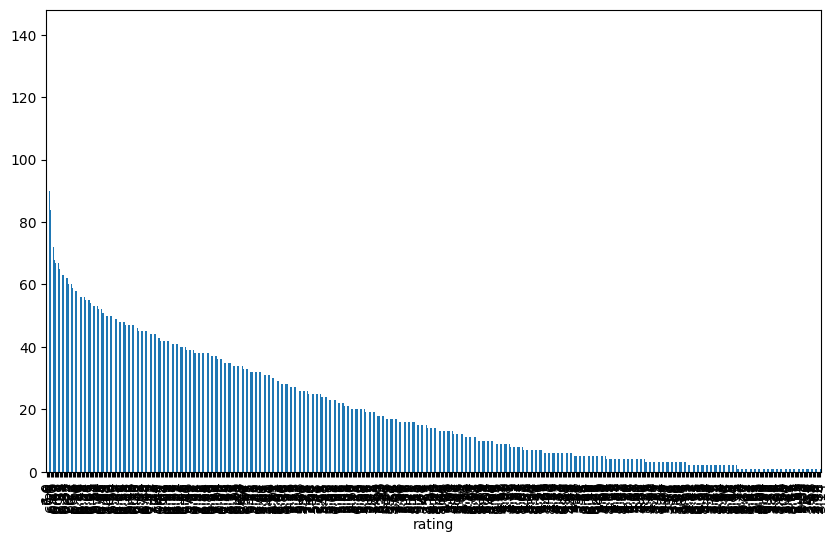

In [14]:
plt.figure(figsize=(10,6)) 
dataframe["rating"].value_counts().plot(kind="bar")  


Feature Extraction:

Decide on the features that will be used for computing similarity (e.g., genres, user ratings).

Convert categorical features into numerical representations if necessary.

Normalize numerical features if required.



In [15]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


In [16]:
le = LabelEncoder()
dataframe['genre'] = le.fit_transform(dataframe['genre'])


In [17]:

# Normalize numerical features
scaler = StandardScaler()
dataframe[['rating', 'members']] = scaler.fit_transform(dataframe[['rating', 'members']])

Recommendation System:

Design a function to recommend anime based on cosine similarity.

Given a target anime, recommend a list of similar anime based on cosine similarity scores. 

Experiment with different threshold values for similarity scores to adjust the recommendation list size.

Analyze the performance of the recommendation system and identify areas of improvement.


In [18]:
from sklearn.metrics.pairwise import cosine_similarity

In [19]:
def recommend_anime(target_anime, similarity_threshold=0.5, num_recommendations=10):
    """
    Recommend anime based on cosine similarity.
     Parameters:
    - target_anime (str): Name of the target anime.
    - similarity_threshold (float): Minimum similarity score for recommendations.
    - num_recommendations (int): Number of recommendations to return.

    Returns:
    - recommendations (list): List of recommended anime names.
    """
     #Calculate cosine similarity matrix
    similarity_matrix = cosine_similarity(dataframe[['genre', 'rating', 'members']])



In [20]:
# Get index of target anime
target_index = dataframe[dataframe['name'] == dataframe.iloc[0]['name']].index[0]


In [21]:
dataframe[['genre','rating', 'members']] = dataframe[['genre', 'rating', 'members']].fillna(0)

In [22]:
similarity_matrix = cosine_similarity(dataframe[['genre', 'rating']].values)

In [23]:
target_similarity = similarity_matrix[target_index]

In [24]:
similarity_threshold = 0.7 # set your desired threshold values
similar_anime_indices = [i for i, score in enumerate(target_similarity) if score > similarity_threshold and i != target_index]

In [25]:
similar_anime_indices.sort(key=lambda x: target_similarity[x], reverse=True)


In [26]:
num_recommendations= 5 #or any integer you want
recommendations = dataframe.iloc[similar_anime_indices]['name'].head(num_recommendations).tolist()

In [27]:
def recommend_anime(target_anime, similarity_matrix, threshold):
    recommendations = []
    for anime, similarity in enumerate(similarity_matrix[target_anime]):
        if similarity >= threshold:
            recommendations.append((anime, similarity))
    return sorted(recommendations, key=lambda x: x[1], reverse=True)


In [28]:

# Example usage
target_anime = 0  # index or name of the anime
similarity_matrix = [[0.9, 0.2, 0.6], [0.1, 0.8, 0.3]]  # dummy data
thresholds = [0.3, 0.5, 0.7]


In [29]:

for threshold in thresholds:
    recommendations = recommend_anime(target_anime, similarity_matrix, threshold)
    print(f"Threshold {threshold}: {recommendations}")

Threshold 0.3: [(0, 0.9), (2, 0.6)]
Threshold 0.5: [(0, 0.9), (2, 0.6)]
Threshold 0.7: [(0, 0.9)]


In [48]:
from	sklearn.metrics import precision_score, recall_score	

In [62]:
def evaluate_recommendations(recommendations, relevant_anime):
    # Convert to sets
    recommended = set([anime[0] for anime in recommendations])
    relevant = set(relevant_anime)
    
    # Calculate metrics
    true_positives = len(recommended & relevant)
    precision = true_positives / len(recommended) if recommended else 0
    recall = true_positives / len(relevant) if relevant else 0
    
    return precision, recall

In [63]:
# Example usage
target_anime = 'Naruto'
recommendations = [('Bleach', 0.85), ('One Piece', 0.78), ('Fairy Tail', 0.75)]
relevant_anime = ['Bleach', 'One Piece', 'Attack on Titan']

In [64]:
precision, recall = evaluate_recommendations(recommendations, relevant_anime)
print(f"Precision: {precision:.2f}, Recall: {recall:.2f}")

Precision: 0.67, Recall: 0.67


Interview Questions:
1. Can you explain the difference between user-based and item-based collaborative filtering?

User-Based Collaborative Filtering (UBCF) and Item-Based Collaborative Filtering (IBCF) are two approaches used in recommendation systems.

- User-Based Collaborative Filtering (UBCF):

    - Recommends items to a user based on the preferences of similar users.

    - Finds users with similar preferences (nearest neighbors) and recommends items liked by those users. 

    - Example: If User A and User B have similar preferences, and User B likes Item X, then recommend Item X to User A.

- Item-Based Collaborative Filtering (IBCF):

    - Recommends items similar to the ones a user has liked or interacted with before.

    - Finds items with similar attributes or features (nearest neighbors) and recommends them.

    - Example: If a user likes Item X, and Item X is similar to Item Y, then recommend Item Y to the user.

2. What is collaborative filtering, and how does it work?

Collaborative Filtering (CF) is a technique used in recommendation systems to predict a user's preferences based on the behavior of similar users or items.

- How it Works:
    1. Data Collection: Collect user-item interaction data (e.g., ratings, clicks, purchases).

    2. Matrix Construction: Create a user-item matrix with users as rows and items as columns.

    3. Similarity Calculation: Calculate similarity between users (UBCF) or items (IBCF) using metrics like cosine 
				similarity or Pearson correlation.

    4. Neighborhood Formation: Identify nearest neighbors (similar users or items).

    5. Prediction: Predict ratings or scores for unrated items based on the neighborhood.
				
    6. Recommendation: Recommend top-N items with the highest predicted ratings or scores.